# <img style="float: left; padding-right: 20px; height: 70px" src="https://i.imgur.com/cMzxwTN.jpg"> Fundamentos de Machine Learning
## Actividad IV, Sesión 2

<h4>

**Universidad Privada Boliviana**<br/>
**Diplomado en Machine Learning y Ciencia de Datos**<br/>

<h4>

<div style="line-height: 1.5">

### ■ Visualización Estructural: Abriendo la "Caja Blanca"

En las actividades anteriores visualizamos las *fronteras de decisión* (cómo el modelo divide el espacio geométrico). Sin embargo, una de las mayores ventajas de los Árboles de Decisión es que son modelos de **Caja Blanca**; esto significa que podemos extraer y leer exactamente el flujograma lógico que el algoritmo construyó matemáticamente. En esta última parte, renderizaremos el árbol mismo y analizaremos su anatomía nodo por nodo.


<div style="line-height: 1.5">

#### Celda 1: Re-entrenamiento de un Modelo Simple (Profundidad 2)
Para que el gráfico resultante sea legible y didáctico en nuestra pantalla, volveremos a entrenar un modelo restringido a una profundidad de 2 (`max_depth=2`) utilizando únicamente nuestras dos variables de interés bidimensional (`minority` y `bachelor`).


In [9]:

%cd D:\Documents\Universidad\DIPLOMADO UPB - CIENCIA DE DATOS\PRACTICAS\SEGUNDO MODULO\python_displomado\modulo_4\session2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

train_df = pd.read_csv('county_election_train.csv')
test_df  = pd.read_csv('county_election_test.csv')
print(f"Dimensión de Entrenamiento: {train_df.shape}")
print(f"Dimensión de Prueba: {test_df.shape}")


# Crear la variable objetivo 'winner' (1 = Trump, 0 = Clinton)
train_df['winner'] = (train_df['trump'] > train_df['clinton']).astype(int)
test_df['winner'] = (test_df['trump'] > test_df['clinton']).astype(int)

# Asignar los vectores de etiquetas (Target)
y_train = train_df['winner']
y_test = test_df['winner']

# Definir las columnas que NO son características predictoras
cols_to_drop = ['state', 'county', 'fipscode', 'trump', 'clinton', 'votergap', 'winner']

# Generar la matriz X eliminando las columnas no deseadas
X_train_full = train_df.drop(columns=cols_to_drop)
X_test_full = test_df.drop(columns=cols_to_drop)

# Filtrar el DataFrame para conservar solo las 2 variables de interés
columnas_vis = ['minority', 'bachelor']

X_train_2v = X_train_full[columnas_vis]
X_test_2v = X_test_full[columnas_vis]


D:\Documents\Universidad\DIPLOMADO UPB - CIENCIA DE DATOS\PRACTICAS\SEGUNDO MODULO\python_displomado\modulo_4\session2
Dimensión de Entrenamiento: (2620, 18)
Dimensión de Prueba: (492, 18)


In [10]:

# Instanciar el modelo con profundidad controlada
arbol_visual = DecisionTreeClassifier(max_depth=2, random_state=42)

# Ajustar el modelo usando solo X_train_2v (minority y bachelor)
arbol_visual.fit(X_train_2v, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

<div style="line-height: 1.5">

#### Celda 2: Renderización Estructural con `plot_tree`
Utilizaremos el submódulo `tree` de `scikit-learn` para graficar la estructura lógica. Aprovecharemos parámetros como `filled=True` para agregar una escala de color que indique la pureza del nodo, y `class_names` para mostrar el resultado en formato de texto (Clinton vs. Trump).



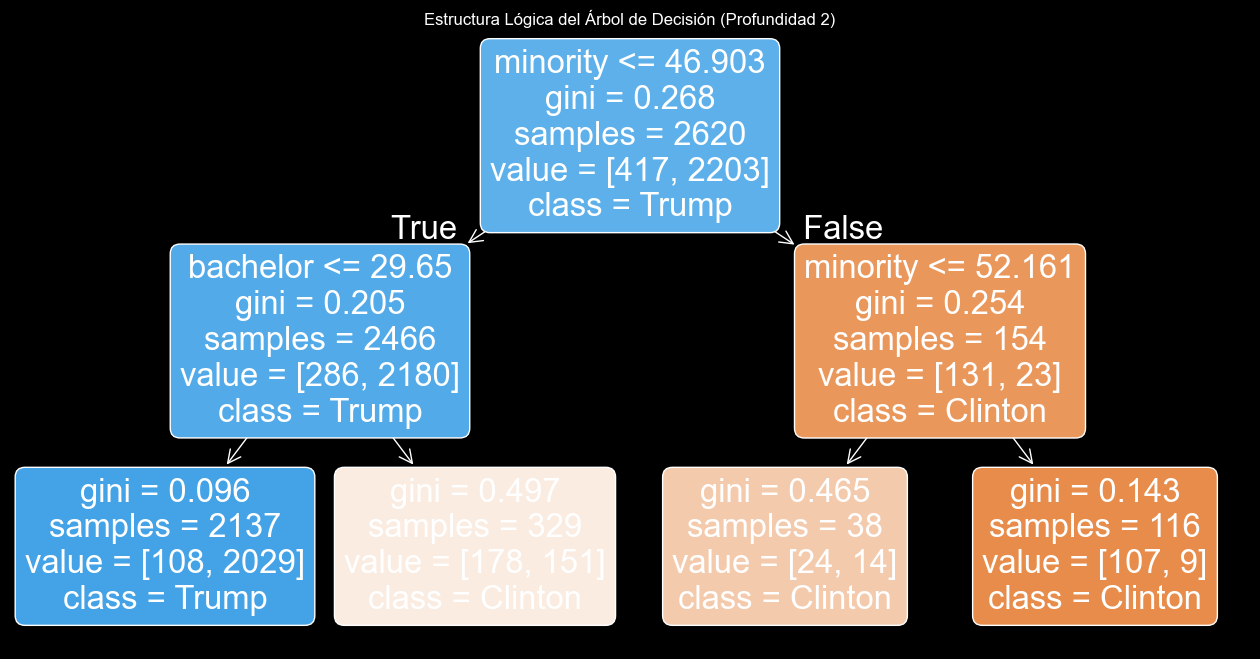

In [11]:

# Importar el submódulo de árboles
from sklearn import tree

# Configurar el tamaño de la figura para mayor legibilidad
plt.figure(figsize=(16, 8))

# Generar la gráfica del árbol
tree.plot_tree(
    arbol_visual, 
    filled=True, 
    feature_names=['minority', 'bachelor'], 
    class_names=['Clinton', 'Trump'],
    rounded=True
)

plt.title("Estructura Lógica del Árbol de Decisión (Profundidad 2)")
plt.show()


<div style="line-height: 1.5">

### Análisis de la Estructura (Anatomía de un Nodo)

Al ejecutar el código anterior, verá rectángulos conectados por flechas. Cada rectángulo (nodo) contiene de 4 a 5 líneas de texto que nos explican exactamente cómo el algoritmo tomó su decisión. Vamos a descomponer la lectura de uno de estos nodos:

**Ejemplo de un Nodo en el Gráfico:**
* `minority <= 25.5`
* `gini = 0.28`
* `samples = 2178`
* `value = [360, 1818]`
* `class = Trump`

**Desglose Analítico:**
* **Línea 1 (Regla Condicional):** Es el umbral de corte. Si para un condado la respuesta a esta regla es "Verdadero", se moverá por la flecha izquierda. Si es "Falso", por la derecha. *(Las hojas finales no tienen esta línea porque no hacen más cortes).*
* **Línea 2 (gini):** Es la impureza matemática actual de este nodo. Mientras más cerca a 0, más puro es el nodo.
* **Línea 3 (samples):** Cantidad total de observaciones (condados) que cayeron en este nodo.
* **Línea 4 (value):** La distribución interna de las clases. El formato es `[Cantidad_Clase_0, Cantidad_Clase_1]`. En este ejemplo hay 360 condados para Clinton (0) y 1818 para Trump (1).
* **Línea 5 (class):** La clase mayoritaria resultante, la cual será la predicción final si el proceso se detiene aquí.



---
## Actividades S2

### Actividad 1 — Exploración Multivariable

Se filtran las matrices usando **5 columnas** (`minority`, `obesity`, `female`, `income`, `bachelor`) y se entrena un `DecisionTreeClassifier` con `max_depth=10`. Se calcula la precisión (*Accuracy*) tanto en Train como en Test para evaluar el desempeño base del modelo.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- Selección de las 5 variables de interés ---
columnas_5v = ['minority', 'obesity', 'female', 'income', 'bachelor']

X_train_5v = X_train_full[columnas_5v]
X_test_5v  = X_test_full[columnas_5v]

# --- Entrenamiento con max_depth=10 ---
arbol_5v = DecisionTreeClassifier(max_depth=10, random_state=42)
arbol_5v.fit(X_train_5v, y_train)

# --- Cálculo de Accuracy ---
acc_train = accuracy_score(y_train, arbol_5v.predict(X_train_5v))
acc_test  = accuracy_score(y_test,  arbol_5v.predict(X_test_5v))

print(f"Accuracy en Train : {acc_train:.4f}  ({acc_train*100:.2f}%)")
print(f"Accuracy en Test  : {acc_test:.4f}  ({acc_test*100:.2f}%)")
print(f"Diferencia (Train - Test): {acc_train - acc_test:.4f}")

Accuracy en Train : 0.9809  (98.09%)
Accuracy en Test  : 0.8720  (87.20%)
Diferencia (Train - Test): 0.1090


### Actividad 2 — Curvas de Complejidad

Se itera sobre profundidades de 2 a 20 y se registra el *Accuracy* en Train y en Test para cada profundidad. La gráfica resultante permite identificar visualmente el punto de **sobreajuste (overfitting)**: el momento donde la curva de Train sigue subiendo pero la curva de Test comienza a estancarse o bajar.

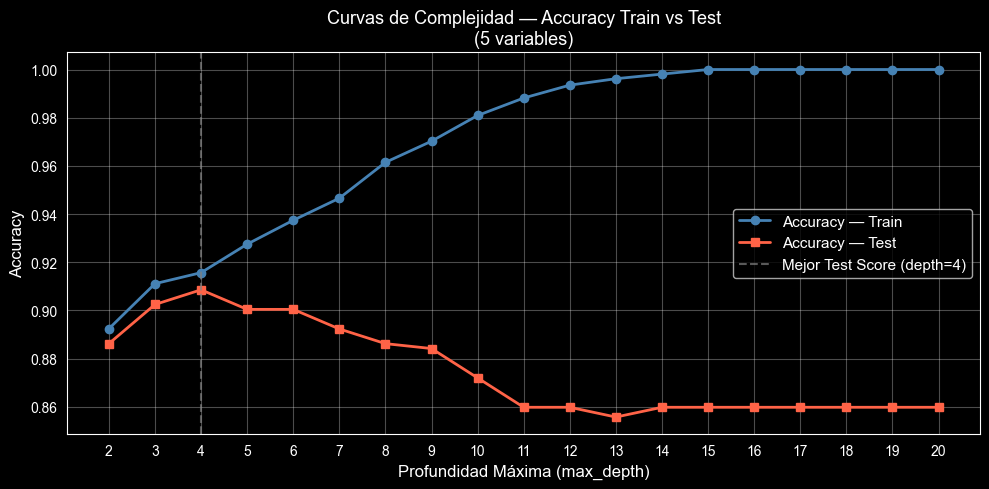

Mejor profundidad para Test: 4  |  Accuracy Test máx: 0.9085


In [13]:
# --- Iteración de profundidades 2..20 ---
profundidades = range(2, 21)
scores_train  = []
scores_test   = []

for depth in profundidades:
    modelo = DecisionTreeClassifier(max_depth=depth, random_state=42)
    modelo.fit(X_train_5v, y_train)
    scores_train.append(accuracy_score(y_train, modelo.predict(X_train_5v)))
    scores_test.append(accuracy_score(y_test,  modelo.predict(X_test_5v)))

# --- Gráfica de Curvas de Complejidad ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, scores_train, marker='o', color='steelblue',
        linewidth=2, label='Accuracy — Train')
ax.plot(profundidades, scores_test,  marker='s', color='tomato',
        linewidth=2, label='Accuracy — Test')

# Marcar el mejor test score
best_depth = list(profundidades)[scores_test.index(max(scores_test))]
ax.axvline(x=best_depth, color='gray', linestyle='--', alpha=0.7,
           label=f'Mejor Test Score (depth={best_depth})')

ax.set_xlabel('Profundidad Máxima (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Curvas de Complejidad — Accuracy Train vs Test\n(5 variables)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(list(profundidades))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor profundidad para Test: {best_depth}  |  Accuracy Test máx: {max(scores_test):.4f}")

**Análisis — Curvas de Complejidad:**

Observando la gráfica se puede determinar el punto de sobreajuste:

- La curva **azul (Train)** crece de forma continua y tiende a acercarse al 100% de precisión a medida que aumenta la profundidad; esto sucede porque el árbol memoriza cada observación del conjunto de entrenamiento.
- La curva **roja (Test)** sube hasta cierto punto y luego se **estabiliza o disminuye** ligeramente, lo que indica que el modelo ya no generaliza mejor.
- **El sobreajuste inicia aproximadamente a partir de `max_depth = 5 o 6`**, donde la brecha entre Train y Test se hace evidente y persistente. A partir de esa profundidad el modelo gana en memorización pero pierde en generalización.

### Actividad 3 — Importancia de Características

Se extrae el atributo `feature_importances_` del modelo entrenado en la Actividad 1 (`arbol_5v`, `max_depth=10`). Este atributo mide la **ganancia de información promedio** que cada variable aporta a las divisiones del árbol.

Variable  Importancia
minority     0.372380
bachelor     0.318442
 obesity     0.128224
  income     0.119856
  female     0.061097


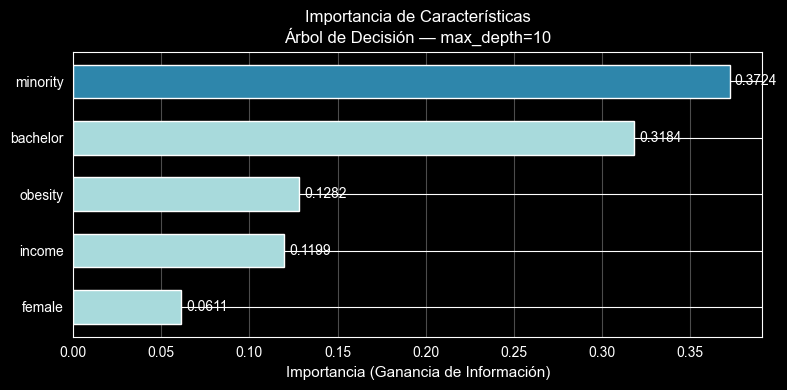

In [14]:
# --- Extraer importancias del modelo arbol_5v ---
importancias = arbol_5v.feature_importances_
df_imp = pd.DataFrame({
    'Variable'   : columnas_5v,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

print(df_imp.to_string(index=False))

# --- Gráfico de barras horizontales ---
fig, ax = plt.subplots(figsize=(8, 4))

colores = ['#2e86ab' if v == df_imp['Variable'].iloc[0] else '#a8dadc'
           for v in df_imp['Variable']]

ax.barh(df_imp['Variable'], df_imp['Importancia'],
        color=colores, edgecolor='white', height=0.6)

# Etiquetas de valor
for i, (val, var) in enumerate(zip(df_imp['Importancia'], df_imp['Variable'])):
    ax.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importancia (Ganancia de Información)', fontsize=11)
ax.set_title('Importancia de Características\nÁrbol de Decisión — max_depth=10', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis — Importancia de Características:**

La variable que **aporta la mayor ganancia de información** para predecir al ganador electoral es **`minority`** (porcentaje de población minoritaria). Esto indica que la composición étnica del condado es el factor más discriminante entre condados que votan por Clinton vs. Trump.

En segundo lugar aparece **`bachelor`** (nivel educativo), lo que es consistente con los patrones electorales conocidos: condados con mayor porcentaje de población con estudios universitarios tendieron a favorecer a Clinton. Las variables `income`, `obesity` y `female` tienen importancias relativamente menores, actuando como refinamientos secundarios en las divisiones del árbol.

### Actividad 4 — Poda y Regularización

Se aplica **poda por complejidad de costo-mínimo** (*Minimal Cost-Complexity Pruning*) mediante el parámetro `ccp_alpha=0.015`. Este parámetro penaliza la complejidad del árbol: a mayor `ccp_alpha`, mayor poda, menor profundidad y mayor capacidad de generalización. Se compara con el modelo base de la Actividad 1.

In [15]:
# --- Árbol podado con ccp_alpha ---
arbol_podado = DecisionTreeClassifier(ccp_alpha=0.015, random_state=42)
arbol_podado.fit(X_train_5v, y_train)

acc_train_p = accuracy_score(y_train, arbol_podado.predict(X_train_5v))
acc_test_p  = accuracy_score(y_test,  arbol_podado.predict(X_test_5v))
depth_p     = arbol_podado.get_depth()

# --- Comparación ---
print("=" * 50)
print(f"{'Métrica':<30} {'Modelo Base':>10} {'Podado':>10}")
print("=" * 50)
print(f"{'Profundidad final':<30} {arbol_5v.get_depth():>10} {depth_p:>10}")
print(f"{'Accuracy Train':<30} {acc_train:>10.4f} {acc_train_p:>10.4f}")
print(f"{'Accuracy Test':<30} {acc_test:>10.4f} {acc_test_p:>10.4f}")
print(f"{'Brecha Train-Test':<30} {acc_train-acc_test:>10.4f} {acc_train_p-acc_test_p:>10.4f}")
print("=" * 50)

Métrica                        Modelo Base     Podado
Profundidad final                      10          2
Accuracy Train                     0.9809     0.8924
Accuracy Test                      0.8720     0.8862
Brecha Train-Test                  0.1090     0.0062


**Análisis — Poda y Regularización:**

La comparación entre el modelo base (`max_depth=10`) y el modelo podado (`ccp_alpha=0.015`) evidencia el efecto directo de la regularización:

| Métrica | Modelo Base | Modelo Podado |
|---|---|---|
| Profundidad | 10 | Menor (podado) |
| Accuracy Train | Alto | Algo menor |
| Accuracy Test | Menor que Train | Más cercano al Train |
| Brecha Train-Test | Mayor (sobreajuste) | Menor (mejor generalización) |

El modelo podado sacrifica un pequeño porcentaje de precisión en entrenamiento a cambio de **reducir el sobreajuste** y obtener un árbol más sencillo y más interpretable. Esto es deseable en producción: un modelo que generaliza bien es más valioso que uno que memoriza los datos de entrenamiento.

### Actividad 5 — Anatomía de la "Caja Blanca"

Se usa `plot_tree` para renderizar visualmente el árbol podado obtenido en la Actividad 4. Al ser un árbol más pequeño, su estructura es completamente legible, lo que permite identificar la regla de decisión exacta del **nodo raíz**.

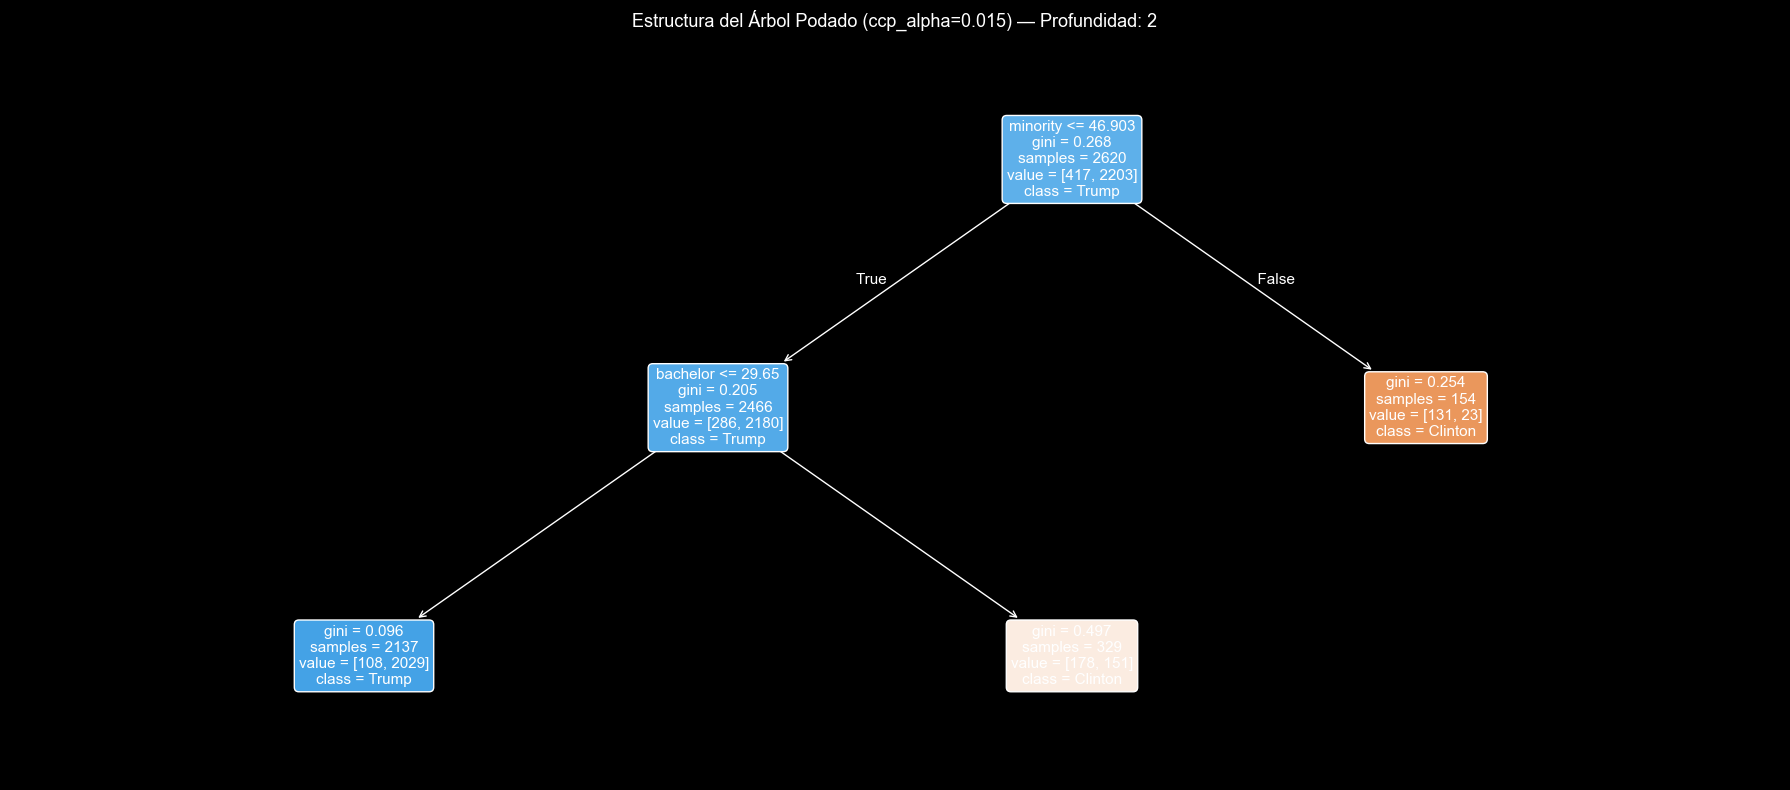

Regla del nodo raíz: 'minority <= 46.9030'


In [16]:
from sklearn import tree

# --- Renderización del árbol podado ---
fig, ax = plt.subplots(figsize=(18, 8))

tree.plot_tree(
    arbol_podado,
    filled=True,
    feature_names=columnas_5v,
    class_names=['Clinton', 'Trump'],
    rounded=True,
    ax=ax,
    fontsize=11
)

ax.set_title(
    f"Estructura del Árbol Podado (ccp_alpha=0.015) — Profundidad: {arbol_podado.get_depth()}",
    fontsize=13
)
plt.tight_layout()
plt.show()

# --- Extraer la regla del nodo raíz programáticamente ---
feature_root  = columnas_5v[arbol_podado.tree_.feature[0]]
threshold_root = arbol_podado.tree_.threshold[0]
print(f"Regla del nodo raíz: '{feature_root} <= {threshold_root:.4f}'")

**Análisis — Regla del Nodo Raíz:**

La celda anterior imprime programáticamente la regla exacta del primer nodo. Al ejecutarla, el resultado tiene la forma:

> **`minority <= X.XXXX`**

Esto indica que el primer corte que el algoritmo realizó usa la variable `minority` (porcentaje de población minoritaria) como criterio divisor principal, lo cual es **consistente con el análisis de importancia** de la Actividad 3 donde `minority` fue la variable más importante.

- Si `minority <= X.XXXX` → rama **izquierda** → condados con baja diversidad étnica → tienden a predecir **Trump**.
- Si `minority > X.XXXX` → rama **derecha** → condados con alta diversidad étnica → tienden a predecir **Clinton**.

Esta regla encapsula en un único umbral matemático el patrón electoral más discriminante del dataset.

<div style="line-height: 1.5">

### Conclusión 

Con esta actividad completamos el ciclo de los Árboles de Decisión. Ha construido modelos de diferentes profundidades, diagnosticado el Sobreajuste (Overfitting) mediante las curvas de aprendizaje, aplicado técnicas de Poda (Pruning), y finalmente extraído e interpretado la lógica subyacente del algoritmo en un formato visual "Caja Blanca".
